In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fraud = pd.read_csv("../data/raw/Fraud_Data.csv")

ip_country = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

credit = pd.read_csv("../data/raw/creditcard.csv")

In [3]:
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
fraud.shape

(151112, 11)

The Fraud_Data dataset contains 151,112 transactions and 11 variables.

In [5]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [8]:
fraud.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [9]:
fraud["signup_time"] = pd.to_datetime(
    fraud["signup_time"]
)

fraud["purchase_time"] = pd.to_datetime(
    fraud["purchase_time"]
)

Class Imbalance Analysis

In [10]:
fraud["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [11]:
fraud["class"].value_counts(normalize=True)*100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

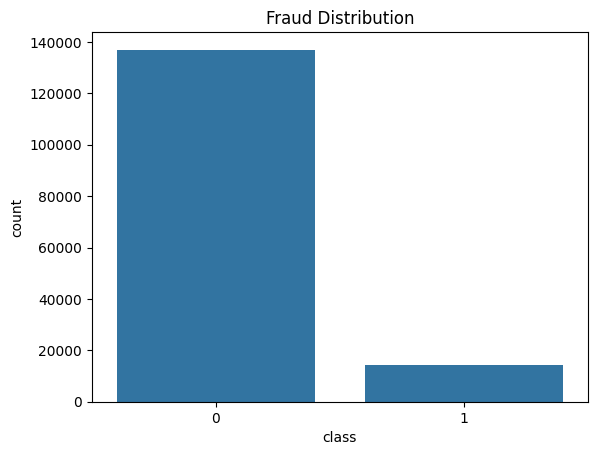

In [12]:
sns.countplot(
    x="class",
    data=fraud
)

plt.title("Fraud Distribution")
plt.show()

The dataset is imbalanced, with legitimate transactions representing approximately 90% of observations and fraudulent transactions representing only 10%. This imbalance must be considered during model training.

<Axes: xlabel='purchase_value', ylabel='Count'>

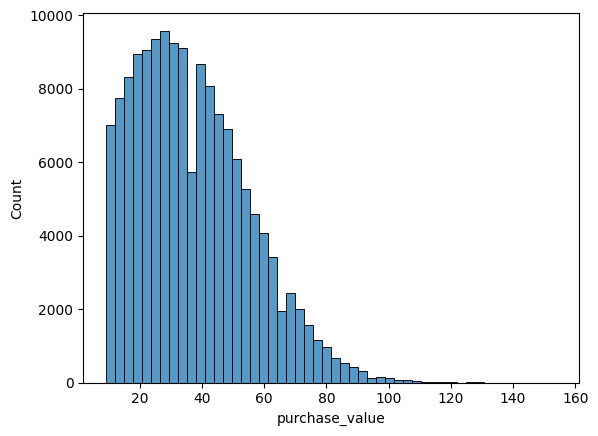

In [13]:
sns.histplot(
    fraud["purchase_value"],
    bins=50
)

Most transactions occur at lower purchase values, with fewer high-value transactions.

<Axes: xlabel='age', ylabel='Count'>

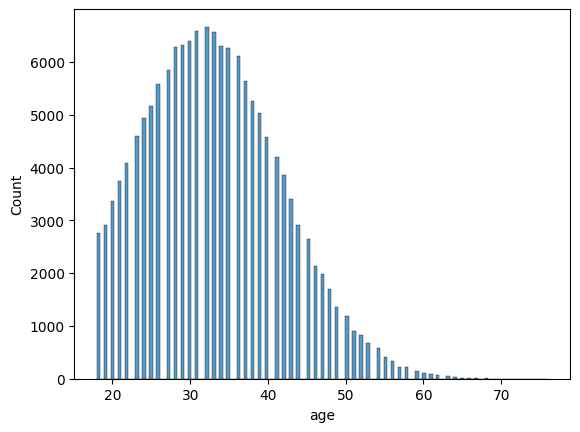

In [14]:
sns.histplot(
    fraud["age"]
)

Purchase Value vs Fraud

<Axes: xlabel='class', ylabel='purchase_value'>

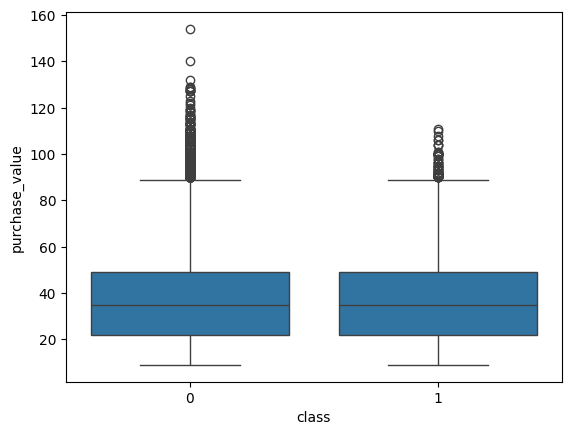

In [15]:
sns.boxplot(
    x="class",
    y="purchase_value",
    data=fraud
)

Age vs Fraud

<Axes: xlabel='class', ylabel='age'>

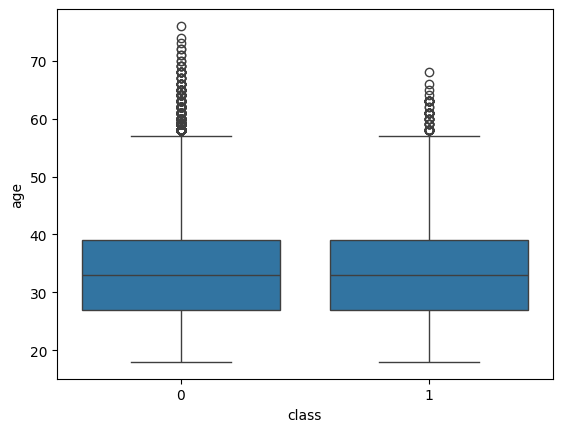

In [16]:
sns.boxplot(
    x="class",
    y="age",
    data=fraud
)

Browser vs Fraud

In [17]:
pd.crosstab(
    fraud["browser"],
    fraud["class"]
)

class,0,1
browser,,
Chrome,55363,6069
FireFox,22268,2342
IE,33540,3187
Opera,3348,328
Safari,22442,2225


In [18]:
fraud = fraud.sort_values(
    "ip_address"
)

ip_country = ip_country.sort_values(
    "lower_bound_ip_address"
)

In [21]:
fraud.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='str')

In [ ]:
fraud["country"]

In [25]:
fraud["ip_address"].describe()

count    1.511120e+05
mean     2.152145e+09
std      1.248497e+09
min      5.209350e+04
25%      1.085934e+09
50%      2.154770e+09
75%      3.243258e+09
max      4.294850e+09
Name: ip_address, dtype: float64

In [26]:
fraud["ip_address"].head(10)

110447     52093.496895
2589       93447.138961
16752     105818.501505
51261     117566.664867
17        131423.789042
15992     155130.397004
27057     155399.107925
38854     159119.791297
149591    166326.775242
11263     207999.643852
Name: ip_address, dtype: float64

In [29]:
fraud["ip_address"].dtype

dtype('float64')

In [32]:
fraud = fraud.sort_values("ip_address")

ip_country = ip_country.sort_values(
    "lower_bound_ip_address"
)

In [33]:
fraud_geo = pd.merge_asof(
    fraud,
    ip_country,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [34]:
fraud_geo = fraud_geo[
    fraud_geo["ip_address"]
    <= fraud_geo["upper_bound_ip_address"]
]

In [35]:
fraud_geo[["ip_address", "country"]].head()

,ip_address,country
634,1.677886e+07,Australia
635,1.684205e+07,Thailand
636,1.684366e+07,China
637,1.693873e+07,China
638,1.697198e+07,Thailand


In [36]:
fraud_geo.shape

(129146, 14)

In [37]:
fraud_geo["country"].value_counts().head(10)

country
United States        58049
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Italy                 1944
Name: count, dtype: int64

Fraud rate per country

In [38]:
country_fraud_rate = (
    fraud_geo.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

top risky countries

In [39]:
country_fraud_rate.head(15)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Name: class, dtype: float64

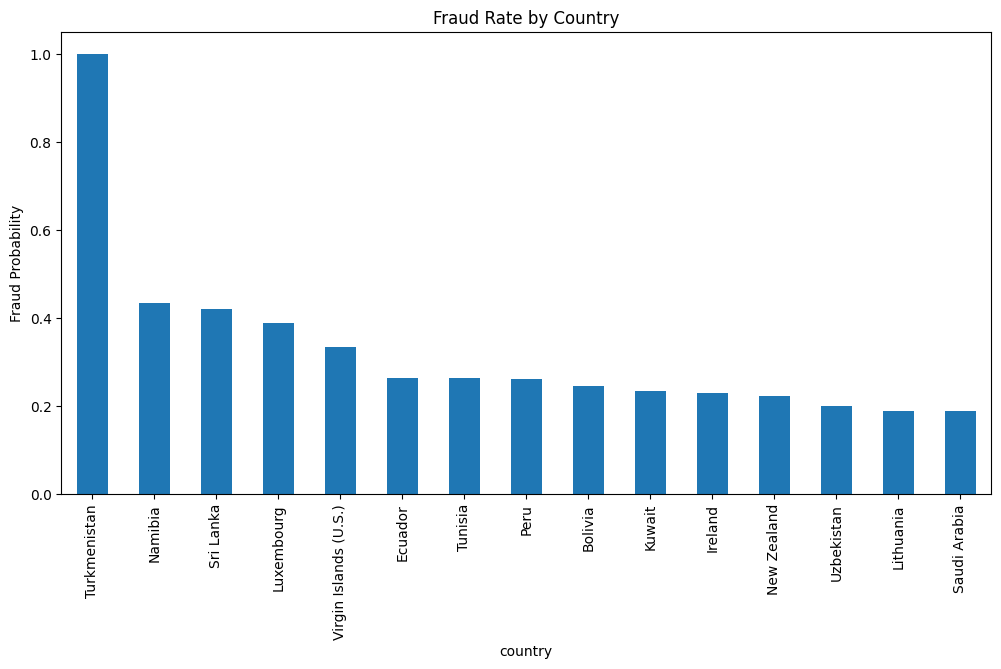

In [40]:
import matplotlib.pyplot as plt

country_fraud_rate.head(15).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Fraud Rate by Country")
plt.ylabel("Fraud Probability")
plt.show()

In [41]:
fraud_geo["country"].value_counts().loc["Turkmenistan"]

np.int64(1)

High fraud rate, but based on extremely small sample size

Turkmenistan has 100% fraud

High-risk countries (examples from your output):
Turkmenistan
Namibia
Sri Lanka
Luxembourg
Ecuador

In [42]:
df = fraud_geo.copy()

TIME-BASED FEATURES

In [43]:
df["signup_time"] = pd.to_datetime(df["signup_time"])
df["purchase_time"] = pd.to_datetime(df["purchase_time"])

In [44]:
df["time_since_signup"] = (
    df["purchase_time"] - df["signup_time"]
).dt.total_seconds()

In [45]:
df["hour_of_day"] = df["purchase_time"].dt.hour

In [46]:
df["day_of_week"] = df["purchase_time"].dt.dayofweek

USER BEHAVIOR FEATURES

Transaction Frequency per User

In [47]:
df["user_transaction_count"] = df.groupby("user_id")["user_id"].transform("count")

Device Reuse Count

In [48]:
df["device_transaction_count"] = df.groupby("device_id")["device_id"].transform("count")

In [49]:
df = pd.get_dummies(df, columns=["country"], drop_first=True)

In [50]:
df = pd.get_dummies(
    df,
    columns=["source", "browser", "sex"],
    drop_first=True
)

In [51]:
df.shape

(129146, 202)

In [52]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,...,country_Yemen,country_Zambia,country_Zimbabwe,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,30,1.677886e+07,0,16778240.0,16779263.0,...,False,False,False,False,True,False,False,False,True,False
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,34,1.684205e+07,0,16809984.0,16842751.0,...,False,False,False,False,True,False,False,False,False,False
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,29,1.684366e+07,0,16843264.0,16843775.0,...,False,False,False,False,False,False,True,False,False,True
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,30,1.693873e+07,0,16924672.0,16941055.0,...,False,False,False,True,False,False,False,False,False,False
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,37,1.697198e+07,0,16941056.0,16973823.0,...,False,False,False,False,True,False,False,False,False,False


In [53]:
df.drop(
    ["signup_time", "purchase_time"],
    axis=1,
    inplace=True
)

In [64]:
df.info()

<class 'pandas.DataFrame'>
Index: 129146 entries, 634 to 131728
Columns: 198 entries, purchase_value to sex_M
dtypes: bool(187), float64(4), int32(2), int64(5)
memory usage: 33.9 MB


In [65]:
X = df.drop("class", axis=1)
y = df["class"]

Train-test split

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 1.0 MB/s eta 0:00:0000:01:00:01

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [70]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote

In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Logistic Regression baseline

In [72]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predictions

In [73]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

Evaluation

In [74]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred)

0.2971084976567336

Confusion Matrix

In [75]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[16201,  7175],
       [  774,  1680]])

AUC-PR

In [76]:
from sklearn.metrics import average_precision_score

average_precision_score(y_test, y_proba)

0.3032860470496721

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.69      0.80     23376
           1       0.19      0.68      0.30      2454

    accuracy                           0.69     25830
   macro avg       0.57      0.69      0.55     25830
weighted avg       0.88      0.69      0.75     25830



In [78]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Precision: 0.18972332015810275
Recall: 0.684596577017115
F1: 0.2971084976567336


Random Forest

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [80]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [81]:
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    average_precision_score
)

print(confusion_matrix(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("AUC-PR:", average_precision_score(y_test, rf_proba))

[[23166   210]
 [ 1079  1375]]
F1: 0.6808615994057935
AUC-PR: 0.6635771257363701


Feature Importance

In [82]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
9,device_transaction_count,0.400552
5,time_since_signup,0.373001
190,source_Direct,0.037797
191,source_SEO,0.030435
196,sex_M,0.022440
192,browser_FireFox,0.015979
193,browser_IE,0.015437
195,browser_Safari,0.015006
6,hour_of_day,0.012956
7,day_of_week,0.012308


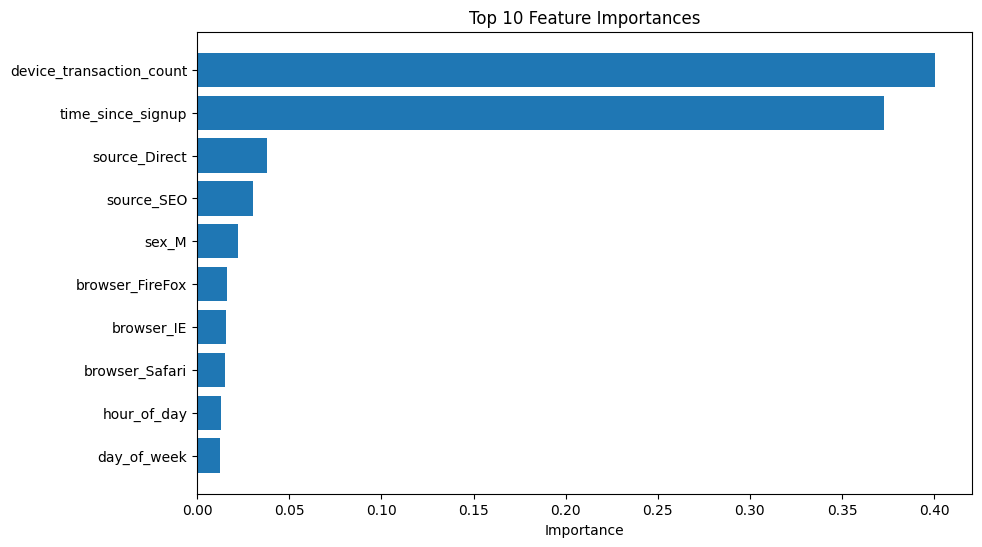

In [83]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()